In [1]:
!pip install transformer-lens transformers accelerate  circuitsvis


  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of torch to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 54.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 821.0/821.0 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 93.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import json
from transformer_lens import loading_from_pretrained as loading
from transformer_lens import  HookedTransformer
import transformer_lens.utilities as utils
from transformer_lens.hook_points import HookPoint
from transformers import AutoTokenizer


import torch.nn.functional as F
import torch
import torch.optim as optim
from sklearn.model_selection import train_test_split
import torch.nn as nn
import einops
import seaborn as sns
from itertools import product
import itertools
import random
import numpy as np
import matplotlib.pyplot as plt
import circuitsvis as cv
import plotly.graph_objects as go
import plotly.io as pio
from IPython.display import display, HTML
from sklearn.decomposition import FastICA
import graphviz
import networkx as nx





In [3]:
from transformer_lens import loading_from_pretrained as loading

# This dictionaries hold all the shorthand aliases mapped to Hugging Face paths
print("Official Short Aliases:")
for alias in loading.MODEL_ALIASES.keys():
    print(f" - {alias}")

print("\nOfficial Checkpoint Collections:")
for official_model in loading.OFFICIAL_MODEL_NAMES:
    print(f" - {official_model}")

Official Short Aliases:
 - 01-ai/Yi-34B
 - 01-ai/Yi-34B-Chat
 - 01-ai/Yi-6B
 - 01-ai/Yi-6B-Chat
 - ai-forever/mGPT
 - allenai/OLMo-1B-hf
 - allenai/OLMo-2-0425-1B
 - allenai/OLMo-2-1124-7B
 - allenai/Olmo-3-32B-Think
 - allenai/Olmo-3-7B-Instruct
 - allenai/Olmo-3-7B-Think
 - allenai/Olmo-3.1-32B-Instruct
 - allenai/Olmo-3.1-32B-Think
 - allenai/OLMo-7B-hf
 - allenai/OLMoE-1B-7B-0924
 - ArthurConmy/redwood_attn_2l
 - Baidicoot/Othello-GPT-Transformer-Lens
 - bigcode/santacoder
 - bigscience/bloom-1b1
 - bigscience/bloom-1b7
 - bigscience/bloom-3b
 - bigscience/bloom-560m
 - bigscience/bloom-7b1
 - codellama/CodeLlama-7b-hf
 - codellama/CodeLlama-7b-Instruct-hf
 - codellama/CodeLlama-7b-Python-hf
 - distilgpt2
 - EleutherAI/gpt-j-6B
 - EleutherAI/gpt-neo-1.3B
 - EleutherAI/gpt-neo-125M
 - EleutherAI/gpt-neo-2.7B
 - EleutherAI/gpt-neox-20b
 - EleutherAI/pythia-1.4b
 - EleutherAI/pythia-1.4b-deduped
 - EleutherAI/pythia-1.4b-deduped-v0
 - EleutherAI/pythia-1.4b-v0
 - EleutherAI/pythia-12b

In [4]:
# 1. Switch to the Instruct variant!
model_id = "gpt2-medium"

tokenizer = AutoTokenizer.from_pretrained(model_id)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/718 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [5]:
model = HookedTransformer.from_pretrained_no_processing(
    model_id,
    device="cuda",
    dtype=torch.float16,
    tokenizer=tokenizer, # Pass the pre-initialized tokenizer to avoid re-loading issues
    default_prepend_bos=False # Explicitly disable prepending BOS token by HookedTransformer
)

model.safetensors:   0%|          | 0.00/1.52G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Loaded pretrained model gpt2-medium into HookedTransformer


In [6]:
def get_device():
    if torch.cuda.is_available():
        return "cuda"
    elif torch.backends.mps.is_available():
        return "mps"
    else:
        return "cpu"

device = get_device()
print(f"Using {device} device")

Using cuda device


In [7]:
def get_loss(mat, components, sparsity='l1'):
  # Ensure mat is on the same device as reconstructed for calculations
  mat_on_device = mat.to(device) # Moved this up for consistent device usage

  # matrix reconstruction loss
  comp_list = []
  n_components = len(components)
  reconstructed = torch.zeros_like(mat_on_device, device=device) # Use mat_on_device for zeros_like reference
  for U,S,V in components:
    #S = S.reshape(1)
    S = F.softplus(S)
    Mi = U @ torch.diag(S) @ (V.T)
    comp_list.append(Mi)
    reconstructed += Mi

  reconstruction_error = ((mat_on_device-reconstructed)**2).mean()

  # Matrix Cosine Similarity Loss
  mat_flat = mat_on_device.flatten()
  reconstructed_flat = reconstructed.flatten()
  matrix_cosine_sim = F.cosine_similarity(mat_flat, reconstructed_flat, dim=0)
  matrix_cosine_loss = (1 - matrix_cosine_sim) # We want to maximize similarity, so minimize (1 - sim)

  #column space orthogonality
  loss_col = torch.tensor(0.0, device=device)
  for i in range(n_components):
        U_i, _, _ = components[i]
        U_i_norm, _ = torch.linalg.qr(U_i.to(torch.float32))
        for j in range(i + 1, n_components):
            U_j, _, _ = components[j]
            U_j_norm, _ = torch.linalg.qr(U_j.to(torch.float32))
            overlap = U_i_norm.T @ U_j_norm
            rank_i = U_i_norm.shape[1]
            rank_j = U_j_norm.shape[1]
            norm_factor = torch.sqrt(torch.tensor(rank_i * rank_j, device=device, dtype=torch.float32))
            loss_col += (torch.norm(overlap, p="fro") / norm_factor)

  loss_row = torch.tensor(0.0,device=device)
  for i in range(n_components):
            _, _, V_i = components[i]
            V_i_norm, _ = torch.linalg.qr(V_i)
            for j in range(i + 1, n_components):
                _, _, V_j = components[j]
                V_j_norm, _ = torch.linalg.qr(V_j)
                overlap = V_i_norm.T @ V_j_norm
                rank_i = V_i_norm.shape[1]
                rank_j = V_j_norm.shape[1]
                norm_factor = torch.sqrt(torch.tensor(rank_i * rank_j,device=device,dtype=torch.float32))
                loss_row += (torch.norm(overlap, p="fro")/ norm_factor)

  if n_components > 1:
        n_pairs = n_components * (n_components - 1) / 2
        loss_col /= n_pairs
        loss_row /= n_pairs

  # Combined loss with new cosine similarity terms
  total_loss = 5*reconstruction_error + 5*loss_col + 3*loss_row + 0.5*matrix_cosine_loss
  return total_loss

In [8]:
def train(mat, n_components=16, n_iterations=65, rank=4):
    d_out, d_in = mat.shape
    components = []
    params = []

    for _ in range(n_components):
        # Create directly on the device to keep them as leaf nodes
        U = torch.empty(d_out, rank, device=device)
        torch.nn.init.xavier_normal_(U)
        U.requires_grad_(True)

        V = torch.empty(d_in, rank, device=device)
        torch.nn.init.xavier_normal_(V)
        V.requires_grad_(True)

        S = torch.ones(rank, device=device, requires_grad=True)

        components.append((U, S, V))
        params.extend([U, S, V])

    optimizer = torch.optim.Adam(params, lr=1e-2)

    # ... rest of your loop

    # --- Scheduler Setup ---
    # mode='min' because we want to reduce LR when loss stops decreasing
    # factor=0.5 means new_lr = lr * 0.5
    # patience=5 means wait 5 epochs of no improvement before dropping LR
    '''scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2   )'''

    for epoch in range(n_iterations):
        optimizer.zero_grad()
        loss = get_loss(mat, components)
        loss.backward()
        optimizer.step()

        # --- Update Scheduler ---
        #scheduler.step(loss)

        print(f"Epoch: {epoch+1}, Loss: {loss.item():.6f}, LR: {optimizer.param_groups[0]['lr']:.6f}")

    return components

In [10]:
from torch.nn.functional import cosine_similarity
def get_matrix_reconstruction_metrics(original_weights,comp_list):
  # Get the original weights and the reconstructed matrix
  original_weights = original_weights.detach().cpu()
  reconstructed_matrix = torch.stack(comp_list, dim=0).sum(dim=0).detach().cpu()

  # Flatten both matrices to 1D vectors for cosine similarity calculation
  original_weights_flat = original_weights.flatten()
  reconstructed_matrix_flat = reconstructed_matrix.flatten()

  # Calculate cosine similarity
  similarity_metric = cosine_similarity(original_weights_flat, reconstructed_matrix_flat, dim=0)

  reconstruction_error = ((original_weights - reconstructed_matrix)**2).mean()
  print(f"Reconstruction MSE: {reconstruction_error.item():.6f}")
  print(f"Cosine Similarity between original and reconstructed weights: {similarity_metric.item():.6f}")
  return reconstruction_error, similarity_metric
# _,_ = get_matrix_reconstruction_metrics(first_head_q,comp_list)


In [12]:
import torch
import statistics

def get_orthogonality_metrics(components):
    # --- Helper for processing overlaps ---
    def process_overlaps(bases):
        all_overlaps = []
        num_bases = len(bases)

        for i in range(num_bases):
            Bi = bases[i]
            rank_i = Bi.shape[1]
            for j in range(i + 1, num_bases):
                Bj = bases[j]
                rank_j = Bj.shape[1]

                overlap = Bi.T @ Bj
                fro_norm = torch.norm(overlap, p='fro')
                norm_factor = torch.sqrt(torch.tensor(rank_i * rank_j, dtype=torch.float32))
                normalized_fro_norm = (fro_norm / norm_factor).item()

                all_overlaps.append(normalized_fro_norm)
                print(f"  Overlap between Component {i+1} and Component {j+1}: {normalized_fro_norm:.6f}")

        avg = statistics.mean(all_overlaps) if all_overlaps else 0.0
        med = statistics.median(all_overlaps) if all_overlaps else 0.0
        return avg, med

    # --- Process Column Space (U) ---
    print("Normalized Frobenius Norm of Overlap for Column Space (U):\n")
    U_bases = [torch.linalg.qr(c[0].to(torch.float32))[0].cpu().detach() for c in components]
    col_avg, col_med = process_overlaps(U_bases)
    print(f"-> Column Space | Avg: {col_avg:.6f}, Median: {col_med:.6f}")

    # --- Process Row Space (V) ---
    print("\nNormalized Frobenius Norm of Overlap for Row Space (V):\n")
    V_bases = [torch.linalg.qr(c[2].to(torch.float32))[0].cpu().detach() for c in components]
    row_avg, row_med = process_overlaps(V_bases)
    print(f"-> Row Space    | Avg: {row_avg:.6f}, Median: {row_med:.6f}")

    return col_avg,col_med,row_avg,row_med
# _,_,_,_ = get_orthogonality_metrics(components)

In [13]:
prompts = [

# Arithmetic
"What is 17 + 28?",
"Calculate 145 - 87.",
"What is 12 times 13?",
"What is 144 divided by 12?",
"What is 25 squared?",
"What is 7 * 8 + 15?",
"What is 100 minus 73?",
"What is 19 + 45?",
"What is 3 cubed?",
"What is 81 divided by 9?",

# General knowledge
"What is the capital of France?",
"What is the largest planet?",
"Who wrote Hamlet?",
"What is the chemical symbol for gold?",
"What is the tallest mountain on Earth?",
"What is the currency of Japan?",
"What is the fastest land animal?",
"Who discovered penicillin?",
"What is the largest ocean?",
"What is the boiling point of water?",

# Science
"Explain photosynthesis briefly.",
"What causes gravity?",
"What is DNA?",
"What is an atom?",
"What is the speed of light?",
"What is a black hole?",
"What is a neuron?",
"What is evolution?",
"What is entropy?",
"What is quantum mechanics?",

# Stories
"Once upon a time there was a dragon",
"A detective entered the abandoned mansion",
"The spaceship landed on Mars",
"A young girl found a mysterious key",
"The king received a strange letter",
"A robot woke up in an empty city",
"A pirate discovered a hidden map",
"The magician opened an ancient book",
"A scientist built a time machine",
"The wolf stared at the moon",

# Reasoning
"If all cats are animals and Tom is a cat, what is Tom?",
"If John is taller than Mike and Mike is taller than Sam, who is tallest?",
"What comes next: 2,4,6,8?",
"If a train travels 60 km in 1 hour, how far in 3 hours?",
"What is the opposite of hot?",
"If today is Monday, what day comes after Wednesday?",
"What color do you get by mixing red and blue?",
"If 5 apples cost 10 dollars, how much does 1 apple cost?",
"What is half of 100?",
"What is bigger, 1/2 or 1/4?",

# Coding
"Write a Python function to add two numbers.",
"What does a for loop do in Python?",
"Explain recursion.",
"What is a dictionary in Python?",
"What is a list comprehension?",
"How do you open a file in Python?",
"What is an array?",
"What is a variable?",
"What is a function?",
"What is object oriented programming?",

# Commonsense
"Why do people wear coats in winter?",
"Why do birds fly?",
"Why do plants need sunlight?",
"Why do humans sleep?",
"Why is water important?",
"Why do cars need fuel?",
"Why do we brush our teeth?",
"Why does ice melt?",
"Why do people exercise?",
"Why do we need food?",

# Continuation
"The capital city of Germany is",
"The largest mammal in the world is",
"The president walked into the room and",
"The weather today is",
"The scientist discovered that",
"The dog chased the",
"The recipe begins with",
"The movie ended when",
"The teacher explained that",
"The book was about",

# Multi-step arithmetic
"What is (12+8)*3?",
"What is 50-(12+8)?",
"What is (7*9)-20?",
"What is 120/(5*2)?",
"What is 13*11?",
"What is 250+175?",
"What is 999-123?",
"What is 14 squared?",
"What is 72/8?",
"What is 5*5*5?",

# Misc
"Describe a beautiful sunset.",
"Explain the internet.",
"What is artificial intelligence?",
"Tell me a joke.",
"Describe a cat.",
"Describe a forest.",
"Explain democracy.",
"What is music?",
"What is friendship?",
"Describe the ocean."
]

In [14]:
def run_with_reconstructed_head(prompt, layer, head, Wq_recon):
    """
    Run the model on `prompt`, but replace the Q projection of `head` at `layer`
    with the low-rank reconstruction `Wq_recon` (same shape as `Mi` / `first_head_q`,
    i.e. [d_head, d_model]).

    We re-derive Q for that head as  x @ Wq_recon.T + b_Q[head] , where `x` is the
    actual normalized residual stream that fed the *real* attention layer on this
    forward pass (captured via a hook). The original bias is kept so that only the
    *weight* reconstruction error propagates downstream -- everything else in the
    model (all other heads, all other layers) is untouched.

    Returns the full logits tensor [batch, pos, d_vocab].
    """
    cache = {}

    def save_x(act, hook):
        cache["x"] = act.detach()
        return act

    def patch_q(act, hook):
        x = cache["x"]                                              # [batch, pos, d_model]
        Wq = Wq_recon.to(act.dtype).to(act.device)                  # [d_head, d_model]
        b_q_head = model.blocks[layer].attn.b_Q[head].to(act.dtype) # [d_head]
        recon_q_head = x.to(act.dtype) @ Wq.T + b_q_head            # [batch, pos, d_head]
        act = act.clone()
        act[:, :, head, :] = recon_q_head
        return act

    logits = model.run_with_hooks(
        prompt,
        fwd_hooks=[
            (f"blocks.{layer}.ln1.hook_normalized", save_x),
            (f"blocks.{layer}.attn.hook_q", patch_q),
        ],
    )
    return logits

In [17]:
def get_component_activation_contributions(comp_list, x_all, h_target_all):
    """
    For each component M_i, computes:
      h_i      = x @ M_i.T                                (per-token activation contribution)
      norm_i   = h_i.norm(dim=-1).mean()                   (average magnitude of that contribution)
      cos_target_i = cosine_similarity(h_i, h_target)      (alignment with the real, ground-truth Q activation)
      cos_total_i  = cosine_similarity(h_i, h_recon_total) (alignment with the full reconstruction, i.e.
                                                              how much this component overlaps with the
                                                              combined output of all components)
    """
    h_list = []
    for Mi in comp_list:
        Mi = Mi.to(x_all.device).float()
        h_i = x_all @ Mi.T  # [total_tokens, d_head]
        h_list.append(h_i)

    h_recon_total = torch.stack(h_list, dim=0).sum(dim=0)  # [total_tokens, d_head]

    norms, cos_targets, cos_totals = [], [], []
    for h_i in h_list:
        norms.append(h_i.norm(dim=-1).mean().item())
        cos_targets.append(F.cosine_similarity(h_i, h_target_all, dim=-1).mean().item())
        cos_totals.append(F.cosine_similarity(h_i, h_recon_total, dim=-1).mean().item())

    return norms, cos_targets, cos_totals


# component_norms, component_cos_target, component_cos_total = get_component_activation_contributions(
#     comp_list, x_all, h_target_all
# )

# total_norm = sum(component_norms)

# print(f"{'Component':>10} | {'norm_i':>10} | {'% of total':>11} | {'cos vs target':>14} | {'cos vs total recon':>19}")
# print("-" * 75)
# for i, (n, ct, cr) in enumerate(zip(component_norms, component_cos_target, component_cos_total)):
#     pct = 100 * n / total_norm
#     print(f"{i:>10} | {n:>10.4f} | {pct:>10.2f}% | {ct:>14.4f} | {cr:>19.4f}")

## All-Heads ICA — Layer-level Sweep

Instead of decomposing a single head, we now iterate over **every attention head**
in the chosen layer, train ICA components for each one's `W_Q`, and collect the full
suite of metrics (matrix reconstruction, orthogonality, logit-level, per-component
activation contributions) into a single summary table.


In [18]:
# ── Configuration ────────────────────────────────────────────────────────────
LAYER          = 5          # which transformer layer to analyse
N_COMPONENTS   = 16         # ICA components per head
N_ITERATIONS   = 65         # training epochs
FACTOR         = 1          # rank = max(1, min(d_head, d_model) // N_COMPONENTS * FACTOR)
TOP_K          = 5          # top-K for agreement metric

n_heads = model.cfg.n_heads
d_model = model.cfg.d_model
d_head  = model.cfg.d_head

print(f"Layer {LAYER} has {n_heads} heads  |  d_model={d_model}, d_head={d_head}")


Layer 5 has 16 heads  |  d_model=1024, d_head=64


In [19]:
import pandas as pd

# Storage: one dict per head, keyed by head index
all_head_results = {}

for head_idx in range(n_heads):

    print("=" * 70)
    print(f"  Processing head {head_idx} / {n_heads - 1}  (layer {LAYER})")
    print("=" * 70)

    # ── 1. Extract W_Q for this head ─────────────────────────────────────────
    #   W_Q shape: [n_heads, d_model, d_head]  →  take [head_idx] → [d_model, d_head]
    #   We work with the transposed form [d_head, d_model] (same as the original notebook)
    w_q_head = model.blocks[LAYER].attn.W_Q[head_idx, :, :].to(torch.float32).T
    # w_q_head: [d_head, d_model]

    # ── 2. Train ICA decomposition ────────────────────────────────────────────
    d_out, d_in = w_q_head.shape            # d_head × d_model
    rank = max(1, min(d_in, d_out) // N_COMPONENTS * FACTOR)
    components = train(w_q_head, n_components=N_COMPONENTS, rank=rank)

    # ── 3. Build component matrices ───────────────────────────────────────────
    comp_list = []
    for U, S, V in components:
        S_act = F.softplus(S)
        Mi = U @ torch.diag(S_act) @ V.T
        comp_list.append(Mi)

    Wq_reconstructed = torch.stack(comp_list).sum(0)   # [d_head, d_model]

    # ── 4. Matrix-level reconstruction metrics ────────────────────────────────
    recon_mse, recon_cos = get_matrix_reconstruction_metrics(w_q_head, comp_list)

    # ── 5. Orthogonality metrics ──────────────────────────────────────────────
    col_avg, col_med, row_avg, row_med = get_orthogonality_metrics(components)

    # ── 6. Collect residual-stream activations across all prompts ─────────────
    xs, h_targets = [], []
    for prompt in prompts:
        _cache = {}
        def _save_x(act, hook):
            _cache["x"] = act.detach()
        def _save_q(act, hook):
            _cache["q"] = act.detach()

        model.run_with_hooks(
            prompt,
            fwd_hooks=[
                (f"blocks.{LAYER}.ln1.hook_normalized", _save_x),
                (f"blocks.{LAYER}.attn.hook_q",         _save_q),
            ],
        )
        xs.append(_cache["x"][0].float())                       # [pos, d_model]
        h_targets.append(_cache["q"][0, :, head_idx, :].float()) # [pos, d_head]

    x_all       = torch.cat(xs,        dim=0).to(device)
    h_target_all = torch.cat(h_targets, dim=0).to(device)

    # ── 7. Logit-level metrics (KL, MSE, top-1/K agreement) ──────────────────
    logit_mse_list, kl_list, top1_list, topk_list = [], [], [], []

    def _run_reconstructed(prompt, Wq_recon):
        _c2 = {}
        def _sx(act, hook):
            _c2["x"] = act.detach()
            return act
        def _pq(act, hook):
            x   = _c2["x"]
            Wq  = Wq_recon.to(act.dtype).to(act.device)
            bq  = model.blocks[LAYER].attn.b_Q[head_idx].to(act.dtype)
            rq  = x.to(act.dtype) @ Wq.T + bq
            act = act.clone()
            act[:, :, head_idx, :] = rq
            return act
        return model.run_with_hooks(
            prompt,
            fwd_hooks=[
                (f"blocks.{LAYER}.ln1.hook_normalized", _sx),
                (f"blocks.{LAYER}.attn.hook_q",         _pq),
            ],
        )

    for prompt in prompts:
        orig_logits  = model(prompt)
        orig_last    = orig_logits[0, -1, :].float()

        recon_logits = _run_reconstructed(prompt, Wq_reconstructed)
        recon_last   = recon_logits[0, -1, :].float()

        logit_mse_list.append(F.mse_loss(recon_last, orig_last).item())

        log_p_orig  = F.log_softmax(orig_last,  dim=-1)
        log_p_recon = F.log_softmax(recon_last, dim=-1)
        kl = F.kl_div(log_p_recon, log_p_orig.exp(), reduction="sum")
        kl_list.append(kl.item())

        t1_orig = orig_last.argmax().item()
        topk_recon = recon_last.topk(TOP_K).indices.tolist()
        top1_list.append(int(t1_orig == recon_last.argmax().item()))
        topk_list.append(int(t1_orig in topk_recon))

    logit_mse     = sum(logit_mse_list) / len(logit_mse_list)
    kl_divergence = sum(kl_list)        / len(kl_list)
    top1_agreement = sum(top1_list)     / len(top1_list)
    topk_agreement = sum(topk_list)     / len(topk_list)

    # ── 8. Per-component activation contributions ─────────────────────────────
    comp_norms, comp_cos_target, comp_cos_total = get_component_activation_contributions(
        comp_list, x_all, h_target_all
    )

    # ── 9. Store everything ───────────────────────────────────────────────────
    all_head_results[head_idx] = dict(
        # matrix-level
        recon_mse       = recon_mse.item(),
        recon_cos       = recon_cos.item(),
        # orthogonality
        col_avg         = col_avg,
        col_med         = col_med,
        row_avg         = row_avg,
        row_med         = row_med,
        # logit-level
        logit_mse       = logit_mse,
        kl_divergence   = kl_divergence,
        top1_agreement  = top1_agreement,
        topk_agreement  = topk_agreement,
        # per-component lists (kept for later plotting)
        comp_norms      = comp_norms,
        comp_cos_target = comp_cos_target,
        comp_cos_total  = comp_cos_total,
        # keep the trained artefacts so they can be reused
        components      = components,
        comp_list       = comp_list,
        Wq_reconstructed = Wq_reconstructed,
    )

    print(f"  Head {head_idx} done  | recon_mse={recon_mse.item():.4f} "
          f"recon_cos={recon_cos.item():.4f}  KL={kl_divergence:.4f}  "
          f"top1={top1_agreement:.2%}  top{TOP_K}={topk_agreement:.2%}")
    print()

print("All heads processed.")


Streaming output truncated to the last 5000 lines.
  Overlap between Component 3 and Component 8: 0.001073
  Overlap between Component 3 and Component 9: 0.000590
  Overlap between Component 3 and Component 10: 0.000823
  Overlap between Component 3 and Component 11: 0.000987
  Overlap between Component 3 and Component 12: 0.001369
  Overlap between Component 3 and Component 13: 0.000730
  Overlap between Component 3 and Component 14: 0.000482
  Overlap between Component 3 and Component 15: 0.001035
  Overlap between Component 3 and Component 16: 0.001036
  Overlap between Component 4 and Component 5: 0.001958
  Overlap between Component 4 and Component 6: 0.000865
  Overlap between Component 4 and Component 7: 0.002877
  Overlap between Component 4 and Component 8: 0.000696
  Overlap between Component 4 and Component 9: 0.000547
  Overlap between Component 4 and Component 10: 0.002122
  Overlap between Component 4 and Component 11: 0.001866
  Overlap between Component 4 and Component 

## Summary Table — All Heads

In [23]:
summary_rows = []
for h, res in all_head_results.items():
    summary_rows.append({
        "head"           : h,
        "recon_mse"      : round(res["recon_mse"],      6),
        "recon_cos"      : round(res["recon_cos"],      6),
        "col_orth_avg"   : round(res["col_avg"],        6),
        "row_orth_avg"   : round(res["row_avg"],        6),
        "logit_mse"      : round(res["logit_mse"],      6),
        "kl_divergence"  : round(res["kl_divergence"],  6),
        "top1_agreement" : round(res["top1_agreement"], 4),
        f"top{TOP_K}_agreement": round(res["topk_agreement"], 4),
    })

df_summary = pd.DataFrame(summary_rows).set_index("head")
print(df_summary.to_string())


      recon_mse  recon_cos  col_orth_avg  row_orth_avg  logit_mse  kl_divergence  top1_agreement  top5_agreement
head                                                                                                            
0      0.001214   0.964521      0.001531      0.001604   0.236975       0.000328            1.00             1.0
1      0.000638   0.979875      0.001678      0.001574   2.410807       0.001111            1.00             1.0
2      0.000897   0.974692      0.004138      0.001568   1.149037       0.000830            1.00             1.0
3      0.001001   0.972560      0.001605      0.001581   4.266973       0.001271            1.00             1.0
4      0.000757   0.976306      0.001443      0.001635   0.560434       0.000430            1.00             1.0
5      0.000617   0.982448      0.001448      0.001586   0.464147       0.000515            1.00             1.0
6      0.000785   0.977679      0.001377      0.001498   1.180292       0.000730            1.00

## Per-head Visualisation

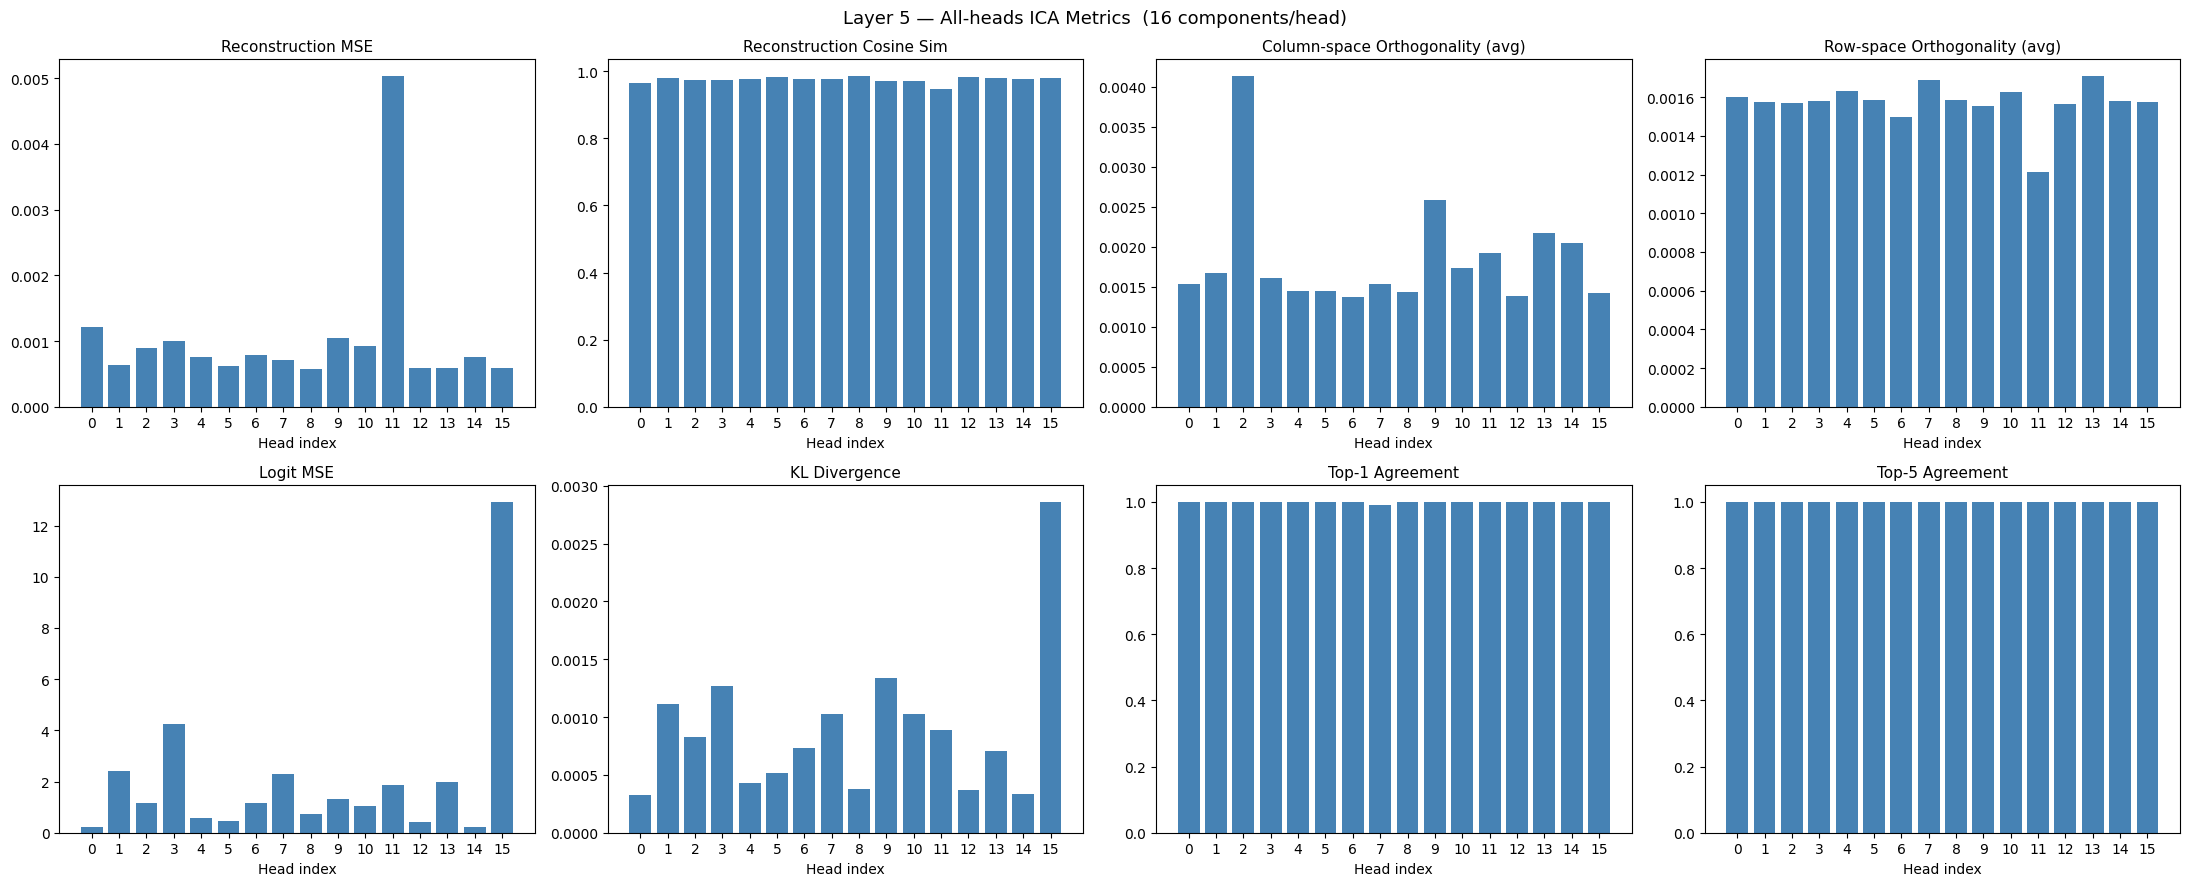

In [20]:
fig, axes = plt.subplots(2, 4, figsize=(22, 9))
axes = axes.flatten()

heads = list(all_head_results.keys())

metric_keys = [
    ("recon_mse",      "Reconstruction MSE"),
    ("recon_cos",      "Reconstruction Cosine Sim"),
    ("col_avg",        "Column-space Orthogonality (avg)"),
    ("row_avg",        "Row-space Orthogonality (avg)"),
    ("logit_mse",      "Logit MSE"),
    ("kl_divergence",  "KL Divergence"),
    ("top1_agreement", "Top-1 Agreement"),
    ("topk_agreement", f"Top-{TOP_K} Agreement"),
]

for ax, (key, title) in zip(axes, metric_keys):
    vals = [all_head_results[h][key] for h in heads]
    ax.bar(heads, vals, color="steelblue")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Head index")
    ax.set_xticks(heads)

plt.suptitle(f"Layer {LAYER} — All-heads ICA Metrics  ({N_COMPONENTS} components/head)", fontsize=13)
plt.tight_layout()
plt.show()


## Per-component Activation Norm — Heat-map (heads × components)

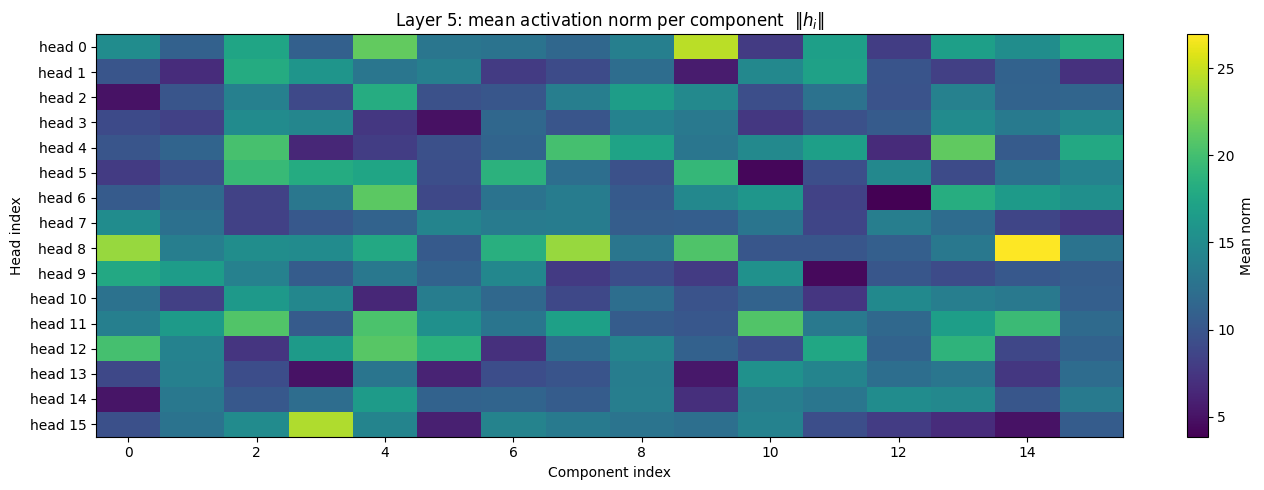

In [21]:
norm_matrix = np.array([all_head_results[h]["comp_norms"] for h in heads])
# shape: [n_heads, N_COMPONENTS]

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(norm_matrix, aspect="auto", cmap="viridis")
ax.set_xlabel("Component index")
ax.set_ylabel("Head index")
ax.set_title(f"Layer {LAYER}: mean activation norm per component  $\\|h_i\\|$")
ax.set_yticks(range(len(heads)))
ax.set_yticklabels([f"head {h}" for h in heads])
plt.colorbar(im, ax=ax, label="Mean norm")
plt.tight_layout()
plt.show()


## Per-component Cosine Similarity vs Ground-Truth Q — Heat-map

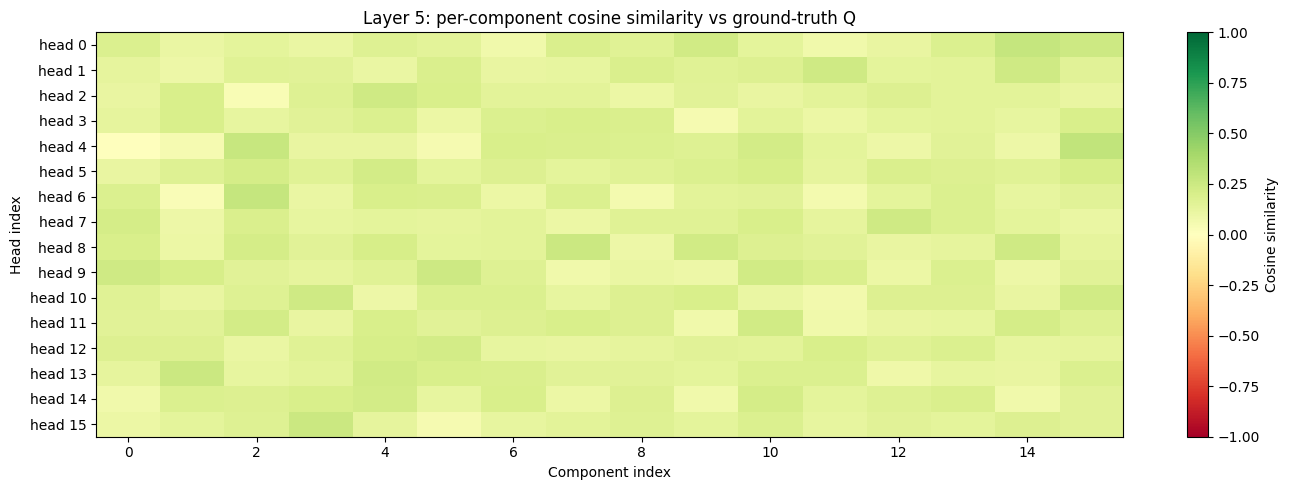

In [22]:
cos_matrix = np.array([all_head_results[h]["comp_cos_target"] for h in heads])

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(cos_matrix, aspect="auto", cmap="RdYlGn", vmin=-1, vmax=1)
ax.set_xlabel("Component index")
ax.set_ylabel("Head index")
ax.set_title(f"Layer {LAYER}: per-component cosine similarity vs ground-truth Q")
ax.set_yticks(range(len(heads)))
ax.set_yticklabels([f"head {h}" for h in heads])
plt.colorbar(im, ax=ax, label="Cosine similarity")
plt.tight_layout()
plt.show()
